# Homework 2 - Gradient

### General Formulation

Consider the function $$f(x) = \displaystyle \frac{1}{2} x^{T}Qx + q^{T}x +20$$
where $Q$ and $c$ are given by:
$$
Q = \left[
\begin{array}{cc}
    10 & 4\\
    4 & 2
\end{array}
\right]
\hbox{ and }
q = \left[
\begin{array}{c}
    -14\\
    -6
\end{array}
\right]
$$Consider

For this problem, $\displaystyle \frac{A}{a} = 30.234$, and
so the linear convergence rate $\delta$ of
the steepest descent algorithm is bounded above by
$\delta = \left( \displaystyle \frac{A/a-1}{A/a+1} \right)^{2} = 0.8760$.


### Problem 1
Consider the function $f(x_1, x_2) = 5(x_1)^2+ (x_2)^2+ 4 x_1x_2 − 14x_1 − 6x_2 + 20$.

<ol>
    <li>Write a py-file to use the steepest descent method to solve the above problem.</li>
    <li>Produce a table for the whole iterations with a random initial point.</li>
    <li> Write a py-file to plot the behavior of the steepest descent method by a contour map. </li>
</ol>

#### 1.1: Steepest descent method to solve $f(x_1,x_2)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Q = np.array([[10.0, 4.0], [4.0, 2.0]])
q = np.array([[-14.0], [-6.0]])
C = 20.0


def objective(x):
    x = np.asarray(x, dtype=float).reshape(2, 1)
    return float((0.5 * x.T @ Q @ x + q.T @ x + C).item())


def gradient(x):
    x = np.asarray(x, dtype=float).reshape(2, 1)
    return Q @ x + q


def steepest_descent(x0, tol=1e-8, max_iter=200, verbose=True):
    x = np.asarray(x0, dtype=float).reshape(2, 1)
    history = []

    for k in range(max_iter + 1):
        grad = gradient(x)
        grad_norm = float(np.linalg.norm(grad))
        if verbose:
            print(f"Iter {k:3d}: f(x) = {objective(x):.6f}, ||grad|| = {grad_norm:.6e}")
        row = {
            "k": k,
            "x": x.copy(),
            "f": objective(x),
            "grad_norm": grad_norm,
            "alpha": None,
        }
        history.append(row)

        if grad_norm < tol:
            break

        alpha = float(((grad.T @ grad) / (grad.T @ Q @ grad)).item())
        if verbose:
            print(f"  Step size alpha = {alpha:.6e}")
        row["alpha"] = alpha
        x = x - alpha * grad

    return x, history

# Run the steepest descent algorithm on specified initial point (40, -100)
x0 = [40, -100]
x_star, history = steepest_descent(x0)
print(f"Optimal solution: x* = {x_star.flatten()}, f(x*) = {objective(x_star):.6f}")
print("Total iterations:", len(history) - 1)


Iter   0: f(x) = 2060.000000, ||grad|| = 4.808326e+01
  Step size alpha = 2.038082e-01
Iter   1: f(x) = 1824.397743, ||grad|| = 5.439037e+01
  Step size alpha = 1.409756e-01
Iter   2: f(x) = 1615.872766, ||grad|| = 4.255715e+01
  Step size alpha = 2.038082e-01
Iter   3: f(x) = 1431.313133, ||grad|| = 4.813940e+01
  Step size alpha = 1.409756e-01
Iter   4: f(x) = 1267.964557, ||grad|| = 3.766615e+01
  Step size alpha = 2.038082e-01
Iter   5: f(x) = 1123.389294, ||grad|| = 4.260684e+01
  Step size alpha = 1.409756e-01
Iter   6: f(x) = 995.429767, ||grad|| = 3.333725e+01
  Step size alpha = 2.038082e-01
Iter   7: f(x) = 882.176364, ||grad|| = 3.771012e+01
  Step size alpha = 1.409756e-01
Iter   8: f(x) = 781.938940, ||grad|| = 2.950587e+01
  Step size alpha = 2.038082e-01
Iter   9: f(x) = 693.221595, ||grad|| = 3.337618e+01
  Step size alpha = 1.409756e-01
Iter  10: f(x) = 614.700351, ||grad|| = 2.611482e+01
  Step size alpha = 2.038082e-01
Iter  11: f(x) = 545.203392, ||grad|| = 2.954032

#### 1.2 Produce a table for the whole iterations with a random initial point

In [4]:
def print_iteration_table(history):
    header = f'{"k":>3} {"x1":>12} {"x2":>12} {"f(x)":>14} {"||grad||":>14} {"alpha":>12}'
    print(header)
    print("-" * len(header))
    for row in history:
        x1, x2 = row["x"].ravel()
        alpha_text = "-" if row["alpha"] is None else f'{row["alpha"]:.8f}'
        print(f'{row["k"]:>3} {x1:>12.6f} {x2:>12.6f} {row["f"]:>14.8f} {row["grad_norm"]:>14.8f} {alpha_text:>12}')

rng = np.random.default_rng(114)
x0 = rng.integers(-8, 9, size=(2, 1)).astype(float)

print("Random initial point x0:")
print(x0)

x_star, history = steepest_descent(x0,verbose=False)
print_iteration_table(history)

Random initial point x0:
[[-6.]
 [ 4.]]
  k           x1           x2           f(x)       ||grad||        alpha
------------------------------------------------------------------------
  0    -6.000000     4.000000   180.00000000    62.03224968   0.08586219
  1    -1.019993     5.888968    14.80114245     1.81601017   2.82941176
  2     0.802306     1.084726    10.13559393     1.75191569   0.08586219
  3     0.942951     1.138074    10.00382945     0.05128779   2.82941176
  4     0.994417     1.002393    10.00010815     0.04947763   0.08586219
  5     0.998389     1.003899    10.00000305     0.00144847   2.82941176
  6     0.999842     1.000068    10.00000009     0.00139735   0.08586219
  7     0.999954     1.000110    10.00000000     0.00004091   2.82941176
  8     0.999996     1.000002    10.00000000     0.00003946   0.08586219
  9     0.999999     1.000003    10.00000000     0.00000116   2.82941176
 10     1.000000     1.000000    10.00000000     0.00000111   0.08586219
 11     1.0

#### 1.3 Write a py-file to plot the behavior of the steepest descent method by a contour map.

Initial point x0: [40, -100]
Approximate minimizer: [1.00020873 0.99954304]
Objective value at x*: 10.0000000451
Exact minimizer: [1. 1.]


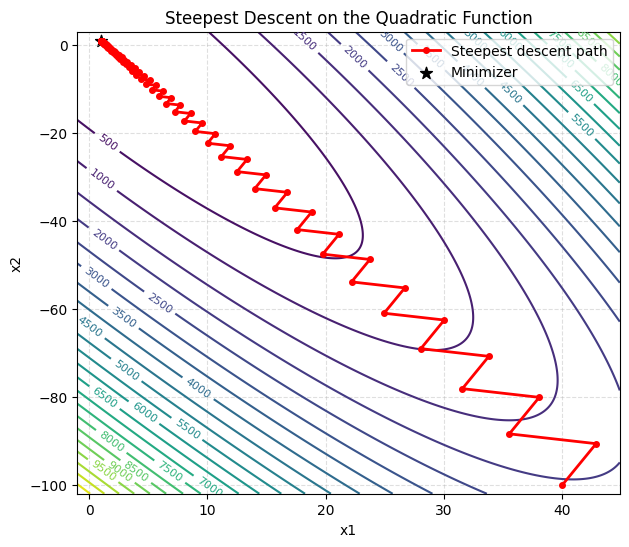

Random initial point x0:
[[-6.]
 [ 4.]]
Approximate minimizer: [1. 1.]
Objective value at x*: 10.0000000000
Exact minimizer: [1. 1.]


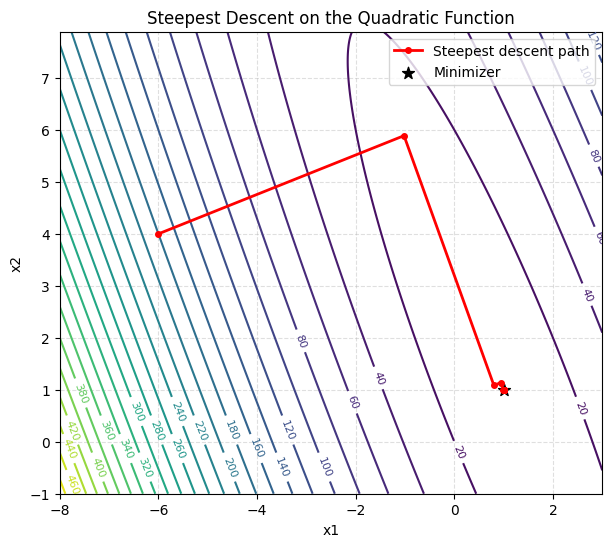

In [7]:
def plot_contours(history):
    points = np.hstack([row["x"] for row in history])
    solution = np.linalg.solve(Q, -q)

    x1_min = min(points[0].min(), solution[0, 0]) - 2.0
    x1_max = max(points[0].max(), solution[0, 0]) + 2.0
    x2_min = min(points[1].min(), solution[1, 0]) - 2.0
    x2_max = max(points[1].max(), solution[1, 0]) + 2.0

    x1 = np.linspace(x1_min, x1_max, 400)
    x2 = np.linspace(x2_min, x2_max, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = 5 * X1**2 + X2**2 + 4 * X1 * X2 - 14 * X1 - 6 * X2 + 20

    plt.figure(figsize=(7, 6))
    contour = plt.contour(X1, X2, Z, levels=25, cmap="viridis")
    plt.clabel(contour, inline=True, fontsize=8)
    plt.plot(points[0], points[1], "o-r", linewidth=2, markersize=4, label="Steepest descent path")
    plt.scatter(solution[0, 0], solution[1, 0], c="black", s=80, marker="*", label="Minimizer")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Steepest Descent on the Quadratic Function")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

# Plot contours and optimization path on specified initial point (40, -100)

x0 = [40, -100]
print("Initial point x0:", x0)
x_star, history = steepest_descent(x0, verbose=False)
print("Approximate minimizer:", x_star.ravel())
print(f"Objective value at x*: {objective(x_star):.10f}")
print("Exact minimizer:", np.linalg.solve(Q, -q).ravel())

plot_contours(history)

# Plot contours and optimization path on random initial point
rng = np.random.default_rng(114)
x0 = rng.integers(-8, 9, size=(2, 1)).astype(float)
print("Random initial point x0:")
print(x0)
x_star, history = steepest_descent(x0, verbose=False)
print("Approximate minimizer:", x_star.ravel())
print(f"Objective value at x*: {objective(x_star):.10f}")
print("Exact minimizer:", np.linalg.solve(Q, -q).ravel())
plot_contours(history)


### Problem 2
Consider the function
$$f(x)=x_1-0.6x_2+4x_3+0.25x_4-\sum_{i=1}^{4}\log(x_i)-\log\left(5-\sum_{i=1}^{4}x_i\right).$$

<ol>
    <li>Write a py-file to use the steepest descent method to solve the above problem.</li>
    <li>Produce a table for the iterations: 1-10, 20, 30, 40, 50, 100, 110, 120, with a random initial point.</li>
</ol>

#### 2.1 Write a py-file to use the steepest descent method to solve the above problem.

In [ ]:
import numpy as np

linear_coeff = np.array([1.0, -0.6, 4.0, 0.25])
requested_iterations = list(range(1, 11)) + [20, 30, 40, 50, 100, 110, 120]


def is_feasible_problem2(x):
    x = np.asarray(x, dtype=float)
    return np.all(x > 0.0) and np.sum(x) < 5.0


def objective_problem2(x):
    x = np.asarray(x, dtype=float)
    if not is_feasible_problem2(x):
        return np.inf
    return float(linear_coeff @ x - np.sum(np.log(x)) - np.log(5.0 - np.sum(x)))


def gradient_problem2(x):
    x = np.asarray(x, dtype=float)
    if not is_feasible_problem2(x):
        raise ValueError("x must satisfy x_i > 0 and sum(x) < 5.")
    return linear_coeff - 1.0 / x + np.ones_like(x) / (5.0 - np.sum(x))


def backtracking_line_search_problem2(x, direction, grad, alpha0=1.0, beta=0.5, c1=1e-4):
    alpha = alpha0
    fx = objective_problem2(x)
    directional_derivative = float(grad @ direction)

    while alpha > 1e-14:
        candidate = x + alpha * direction
        if is_feasible_problem2(candidate) and objective_problem2(candidate) <= fx + c1 * alpha * directional_derivative:
            return alpha
        alpha *= beta

    raise RuntimeError("Line search failed to find a feasible descent step.")


def steepest_descent_problem2(x0, tol=1e-8, max_iter=200, verbose=False):
    x = np.asarray(x0, dtype=float)
    if not is_feasible_problem2(x):
        raise ValueError("Initial point must satisfy x_i > 0 and sum(x) < 5.")

    history = []
    for k in range(max_iter + 1):
        grad = gradient_problem2(x)
        grad_norm = float(np.linalg.norm(grad))
        if verbose:
            print(f"Iter {k:3d}: f(x) = {objective_problem2(x):.6f}, ||grad|| = {grad_norm:.6e}")
        row = {
            "k": k,
            "x": x.copy(),
            "f": objective_problem2(x),
            "grad_norm": grad_norm,
            "alpha": None,
        }
        history.append(row)

        if grad_norm < tol or k == max_iter:
            break

        direction = -grad
        alpha = backtracking_line_search_problem2(x, direction, grad)
        if verbose:
            print(f"  Step size alpha = {alpha:.6e}")
        row["alpha"] = alpha
        x = x + alpha * direction

    return x, history

x0 = np.array([0.5, 0.5, 0.5, 0.5])
x_star, history = steepest_descent_problem2(x0, verbose=True)
print("Approximate minimizer:", x_star.ravel())
print(f"Objective value at x*: {objective_problem2(x_star):.10f}")
print("total iterations:", len(history) - 1)


Iter   0: f(x) = 3.998976, ||grad|| = 3.610209e+00
  Step size alpha = 1.250000e-01
Iter   1: f(x) = 2.846865, ||grad|| = 1.829190e+00
  Step size alpha = 5.000000e-01
Iter   2: f(x) = 2.257231, ||grad|| = 2.606668e+00
  Step size alpha = 1.250000e-01
Iter   3: f(x) = 2.048802, ||grad|| = 4.283283e+00
  Step size alpha = 3.125000e-02
Iter   4: f(x) = 1.880239, ||grad|| = 8.552282e-01
  Step size alpha = 1.250000e-01
Iter   5: f(x) = 1.860754, ||grad|| = 1.472603e+00
  Step size alpha = 6.250000e-02
Iter   6: f(x) = 1.830146, ||grad|| = 9.015541e-01
  Step size alpha = 1.250000e-01
Iter   7: f(x) = 1.829126, ||grad|| = 1.782639e+00
  Step size alpha = 6.250000e-02
Iter   8: f(x) = 1.801047, ||grad|| = 1.065808e+00
  Step size alpha = 6.250000e-02
Iter   9: f(x) = 1.763428, ||grad|| = 4.640575e-01
  Step size alpha = 2.500000e-01
Iter  10: f(x) = 1.743865, ||grad|| = 9.370970e-01
  Step size alpha = 6.250000e-02
Iter  11: f(x) = 1.717192, ||grad|| = 4.188199e-01
  Step size alpha = 1.250

#### 2.2 Produce a table for the iterations: 1-10, 20, 30, 40, 50, 100, 110, 120, with a random initial point.

In [11]:
def print_selected_rows_problem2(history, selected_iterations):
    selected = [row for row in history if row["k"] in selected_iterations]
    header = f'{"k":>4} {"x1":>11} {"x2":>11} {"x3":>11} {"x4":>11} {"f(x)":>14} {"||grad||":>12} {"alpha":>12}'
    print(header)
    print("-" * len(header))
    for row in selected:
        x1, x2, x3, x4 = row["x"]
        alpha_text = "-" if row["alpha"] is None else f'{row["alpha"]:.6e}'
        print(f'{row["k"]:>4} {x1:>11.6f} {x2:>11.6f} {x3:>11.6f} {x4:>11.6f} {row["f"]:>14.8f} {row["grad_norm"]:>12.6e} {alpha_text:>12}')
        
x0 = np.random.default_rng(114).uniform(0.1, 0.9, size=4)
print("Random initial point x0:", x0)
x_star, history = steepest_descent_problem2(x0, verbose=False)
print_selected_rows_problem2(history, requested_iterations)


Random initial point x0: [0.68231062 0.21372729 0.44670738 0.66328975]
   k          x1          x2          x3          x4           f(x)     ||grad||        alpha
---------------------------------------------------------------------------------------------
   1    0.698761    0.831834    0.184782    0.778744     2.69605547 1.843536e+00 2.500000e-01
   2    0.706772    1.182609    0.437962    0.937508     2.50181621 2.469289e+00 1.250000e-01
   3    0.686592    1.291268    0.151335    0.967550     2.15713080 2.264675e+00 6.250000e-02
   4    0.682283    1.344331    0.281487    0.983683     2.08263851 1.299692e+00 1.250000e-01
   5    0.667316    1.439139    0.152381    1.006331     2.02953484 2.120059e+00 6.250000e-02
   6    0.662448    1.484041    0.276510    1.016786     1.97334262 1.214848e+00 1.250000e-01
   7    0.646025    1.563153    0.148456    1.028355     1.95004198 2.208981e+00 6.250000e-02
   8    0.641547    1.601913    0.280733    1.034783     1.90550663 1.257412e+00 6.

### Problem 3
Suppose that we seek to minimize
$$
f(x)=\frac{1}{2}x^THx+c^Tx,
$$
where
$$
H=\begin{bmatrix}10 & -18 & 2 \\ -18 & 40 & -1 \\ 2 & -1 & 3\end{bmatrix},
\qquad
c=\begin{bmatrix}12 \\ -47 \\ -8\end{bmatrix}.
$$

Implement the steepest descent method using the following starting points:

* $x_0=(0,0,0)^T$
* $x_0=(15.09,7.66,-6.56)^T$
* $x_0=(11.77,6.42,-4.28)^T$
* $x_0=(4.46,2.25,1.85)^T$
</ul>

The optimal solution is $x^*=(4,3,1)^T$ with $f(x^*)=-50.5$.

In [14]:
import numpy as np

H = np.array([[10.0, -18.0, 2.0], [-18.0, 40.0, -1.0], [2.0, -1.0, 3.0]])
c = np.array([[12.0], [-47.0], [-8.0]])
x_star_exact = np.array([[4.0], [3.0], [1.0]])
starting_points = {
    "x0_1": np.array([[0.0], [0.0], [0.0]]),
    "x0_2": np.array([[15.09], [7.66], [-6.56]]),
    "x0_3": np.array([[11.77], [6.42], [-4.28]]),
    "x0_4": np.array([[4.46], [2.25], [1.85]]),
}


def objective_problem3(x):
    x = np.asarray(x, dtype=float).reshape(3, 1)
    return float((0.5 * x.T @ H @ x + c.T @ x).item())


def gradient_problem3(x):
    x = np.asarray(x, dtype=float).reshape(3, 1)
    return H @ x + c


def steepest_descent_problem3(x0, tol=1e-8, max_iter=500):
    x = np.asarray(x0, dtype=float).reshape(3, 1)
    history = []

    for k in range(max_iter + 1):
        grad = gradient_problem3(x)
        grad_norm = float(np.linalg.norm(grad))
        row = {
            "k": k,
            "x": x.copy(),
            "f": objective_problem3(x),
            "grad_norm": grad_norm,
            "alpha": None,
        }
        history.append(row)

        if grad_norm < tol or k == max_iter:
            break

        direction = -grad
        alpha = float(((direction.T @ direction) / (direction.T @ H @ direction)).item())
        row["alpha"] = alpha
        x = x + alpha * direction

    return x, history


for key, x0 in starting_points.items():
    x_star, history = steepest_descent_problem3(x0)
    print(f"Starting from {key}:",x0.ravel())
    print(f"  Approximate minimizer: {x_star.ravel()}")
    print(f"  Objective value at x*: {objective_problem3(x_star):.10f}")
    print(f"  Distance to exact solution: {np.linalg.norm(x_star - x_star_exact):.6e}")
    print(f"  Iterations used: {len(history) - 1}\n")

Starting from x0_1: [0. 0. 0.]
  Approximate minimizer: [3.99999999 3.         1.00000001]
  Objective value at x*: -50.5000000000
  Distance to exact solution: 1.238324e-08
  Iterations used: 259

Starting from x0_2: [15.09  7.66 -6.56]
  Approximate minimizer: [4.00000526 3.00000221 0.99999645]
  Objective value at x*: -50.5000000000
  Distance to exact solution: 6.719897e-06
  Iterations used: 500

Starting from x0_3: [11.77  6.42 -4.28]
  Approximate minimizer: [4.00000001 3.         0.99999999]
  Objective value at x*: -50.5000000000
  Distance to exact solution: 1.066013e-08
  Iterations used: 474

Starting from x0_4: [4.46 2.25 1.85]
  Approximate minimizer: [3.99999999 3.         1.00000001]
  Objective value at x*: -50.5000000000
  Distance to exact solution: 1.135031e-08
  Iterations used: 173

